Tabii ki! Şimdi geldik sınıflandırma algoritmalarında oldukça sezgisel ve güçlü bir yöntem olan:

---

# 🟩 K-Nearest Neighbors (K-NN)

## (Türkçesi: K-En Yakın Komşu Algoritması)

---

## 📌 Tanım:

K-NN, **bir veri noktasının sınıfını**, ona en yakın olan **K tane komşusunun sınıfına bakarak** belirleyen bir algoritmadır.
Yani:

> "Bu noktaya en yakın K komşu kim? Çoğunluk ne diyorsa ben de onu tahmin ederim."

---

## 🎯 Ne İşe Yarar?

* **Sınıflandırma** (örn: hastalık var mı/yok mu?)
* **Regresyon** (değeri tahmin etme — ayrı bir kullanım)
  Ama senin videonda önce sınıflandırma modeli olarak öğretiliyor olacak.

---

## 🧠 K-NN Nasıl Çalışır?

1. Yeni bir veri noktası geldi (örneğin: X = \[boy, kilo])
2. Eğitim verisindeki tüm noktalara olan **mesafesi hesaplanır**

   * En çok kullanılan: **Öklid Mesafesi**
3. En yakın **K adet** nokta seçilir.
4. Bu noktaların **etiket çoğunluğuna** göre yeni verinin sınıfı belirlenir.

---

## 🧮 Öklid Mesafesi (Klasik):

İki nokta (x1, y1) ve (x2, y2) için:

```
mesafe = √[(x1 - x2)² + (y1 - y2)²]
```

---

## ✅ Örnek:

Diyelim eğitim verisi şöyle:

| Boy | Kilo | Etiket     |
| --- | ---- | ---------- |
| 160 | 55   | 0 (zayıf)  |
| 170 | 70   | 1 (normal) |
| 180 | 90   | 1 (normal) |

Yeni bir kişi: boy = 175, kilo = 80

* Bu kişinin etiketini K-NN ile bulacağız
* K = 3 ise → en yakın 3 komşuya bakarız
* Komşuların etiketleri: `[1, 1, 0]` → Çoğunluk: **1**

> Tahmin = **1 (normal)**

---

## ⚙️ K Değeri Nasıl Seçilir?

* K = 1 → Aşırı hassas (overfitting olabilir)
* K çok büyük → Aşırı genelleme (underfitting olabilir)

Genelde:

* **K tek sayı** seçilir (eşitliği önlemek için)
* Deneme-yanılma veya çapraz doğrulama (cross-validation) ile en uygun K bulunur

---

## 📊 Avantajları:

✅ Basit, anlaşılır
✅ Eğitimi gerekmez → “**Lazy learner**” (model anında karar verir)
✅ Küçük veri setlerinde iyi çalışır

---

## ⚠️ Dezavantajları:

❌ Büyük veri setlerinde yavaştır (her tahmin için tüm veriyle karşılaştırma yapar)
❌ Özelliklerin ölçek farkından etkilenir
→ Bu yüzden **feature scaling (standardizasyon)** yapılması **şarttır**
❌ Gereksiz özellikler (irrelevant features) performansı bozar

---

## 💻 Python Örneği (sklearn ile):

```python
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
```

---

## 📦 Özetle:

| Özellik           | Açıklama                                       |
| ----------------- | ---------------------------------------------- |
| Model tipi        | Sınıflandırma (veya regresyon)                 |
| Karar mekanizması | En yakın K komşunun sınıfına bakarak tahmin    |
| Mesafe fonksiyonu | Öklid genelde, ama diğerleri de kullanılabilir |
| Model tipi        | Lazy learning (model yok, veriye anlık bakar)  |
| Ölçekleme         | ✅ Gerekli (StandardScaler ile)                 |

---

## 🔍 Son Not:

K-NN, özellikle eğitim için mükemmel bir başlangıç modelidir çünkü:

* Kavraması kolaydır
* Sonuçlar görsel olarak da anlaşılır (2D-3D çizimlerle çok güzel anlatılır)
* Ama **ölçekleme yapılmazsa** sonuçlar yanıltıcı olur!

---

Video sonrası birlikte veri üzerinde KNN kullanmak, K değerini denemek, görselleştirmek istersen hemen desteklerim.

Sonraki konu: **SVM** olacak, geçince yine haber ver 🙂


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset = pd.read_csv('Social_Network_Ads.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [4]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [5]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2) # ASLINDA BU DEĞERLER DEFAULT
classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [6]:
print(classifier.predict(sc.transform([[30,87000]])))

[0]


In [7]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]]


In [9]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred) #ASLINDA LOGISTIC REGRESSİONDAN DAHA İYİ SONUÇLAR VERDİĞİNİ GÖRÜYORUZ

[[64  4]
 [ 3 29]]


0.93

## Visualising the Training set results
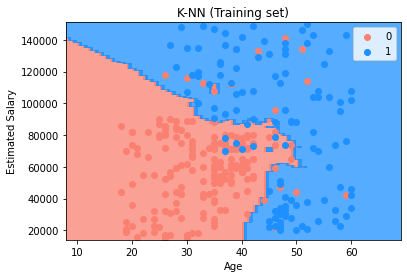

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('K-NN (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

## Visualising the Test set results
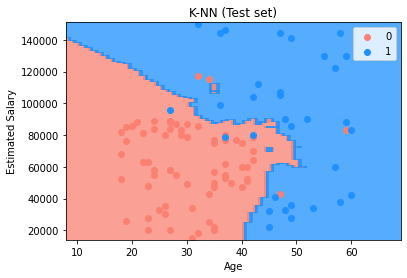

In [ ]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('K-NN (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()